In [7]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import pickle
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/nebular_stuff'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, make_tall_subplots
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


import numpy as np
import h5py
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Key emission lines for reference (rest-frame wavelengths in Angstroms)
emission_lines = {
    r"[OII] $\lambda$3727": 3727.0,
    r"H$\beta$": 4861.0,
    r"[OIII] $\lambda$4959": 4959.0,
    r"[OIII] $\lambda$5007": 5007.0,
    r"H$\alpha$": 6563.0,
    r"[NII] $\lambda$6584": 6584.0,
    r"[SII] $\lambda$6717": 6717.0,
    r"[SII] $\lambda$6731": 6731.0,
}


%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [9]:
folder_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar_viz_haew/"

In [10]:
mstar_bin = "7.50_8.50"


wave = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_gt100.fits")[3].data
flux_100 = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_gt100.fits")[1].data

wave = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_gt100.fits")[3].data
flux_30 = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_lt30.fits")[1].data

cont_norm_mask = (wave > 5200) & (wave < 5800)

flux_100_cont_val = np.median( flux_100[0][cont_norm_mask] )
flux_30_cont_val = np.median( flux_30[0][cont_norm_mask] )

scale_factor = flux_100_cont_val/flux_30_cont_val

In [11]:
import sys, os
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/plots'))
from line_labels import (LINES, ABSORPTION, label_lines, mark_band, mark_span,
                         configure_cm_font, air_to_vac,
                         FEI_FOREST_AIR, CAI_SERIES_AIR,
                         FEI_FOREST_COLOR, CAI_SERIES_COLOR)


In [15]:
# ---------- the fine-tuning dict ----------
STYLE = {
    "OII3726":  dict(loc="top"),
    "OIII4363": dict(dx = +25,dy = 0.1,noline=True),
    # clipped peaks -> float above the panel, no connector
    "OIII4959": dict(loc="top"),
    "SII6716": dict(loc="top"),
    "Halpha":   dict(loc="top"),
    "Hbeta":   dict(loc="top"),
    "Hgamma":   dict(loc="top"),
    "Hdelta":   dict(loc="top"),
    "Hepsilon":   dict(loc="top"),
    "H8":   dict(dx=2,loc="top"),
    "H9":   dict(dy = 0.365, angle = 0,noline=True),
    "H10":   dict(dy = 0.25, angle = 0,noline=True),
    "H11":   dict(dy = 0.155, angle = 0,noline=True),
    "Pa12":  dict(dy = 0.2+0.02, angle = 0,noline=True),
    "Pa11":  dict(dy = 0.25+0.02, angle = 0,noline=True),
    "Pa13": dict(dy=0.15, angle =0,noline=True),
    "HeI5876": dict(loc="top"),
    "NII5755": dict(hide=True),
    # de-crowd the [NII]+Ha+[SII] complex: shift labels sideways -> slanted lines
    "NII6548":  dict(dx=-12, dy=0.15, noline=True),
    "NII6584":  dict(dx=+25, dy=0.06, noline=True),
    "ClIII5518":  dict(hide=True),
    "ClIII5538":  dict(hide=True),
    # recolour one, hide one
    "OI6300": dict(dx=-10,dy=+0.1,noline=True),
    "SIII6312": dict(dx=+15,dy=0-0.03,noline=True),
    "OI6364":   dict(dx=+7.5, dy=-0.05, noline=True),
    "HeI4471": dict(dx=+3,dy=0.25,noline=True),
    "HeI4026": dict(dy = 0.22, noline=True),
    "HeI6678": dict(dy = 0.075, noline=True),
    "SII4069": dict(dx=+5,dy = 0.23, noline=True),
    "HeI7065": dict(noline=True),
    "ArIII7751": dict(loc="top"),
    "ArIII7136": dict(dx = -10,dy = 0.1,noline=True),
    "HeII4686": dict(noline=False,dy=0.075, end = (4685.710, 0.525) ),
    "ArIV4711": dict(noline=False,dx=+5,dy=0.05, end = (4711.260+3, 0.49)),
    "ArIV4740": dict(noline=False,dx=+5,dy=0.05, end = (4740.120+3, 0.49)),
    "FeIII4658": dict(noline=False,dy=0.075, end = (4658.050, 0.525)),
    "NIII4640": dict(hide=True),
    "CIII4650": dict(hide=True),
    "OII7330": dict(loc="top"),
    "HeI7281": dict(dx=0,dy=+0.35,noline=True, angle = 0),
    "NeIII3869": dict(noline=True,dx=-7.5,dy=0.2),
    "NI7468": dict(noline=True,dy=0.285,dx=+10),
    "NI5200": dict(noline=True,dy=-0.075,dx=+5),
    "FeIII4986": dict(noline=True), 
    "HeI4922": dict(noline=True,dy=-0.025),
    "ClII8579": dict(noline=False,dy=0.16, end = (8578.700+1, 0.6)),
    "OI8446": dict(noline=False,dy=0.25, end = (8446.359 , 0.7) ),
    
}

# ---------- individual ABSORPTION features (drawn below the trace) ----------
# These are the single, clean lines we label one-by-one with label_lines(below=True).
# The multiplet/band groups (Ca II triplet, K I doublet, G band) are NOT here --
# they are drawn as bracketed spans with mark_span() in the plotting cell.
# Labels hang BELOW the trace; `dy` lifts/lowers the label anchor from `fiducial`.
# These y-nudges are first-pass guesses -- tune them per panel after a render.
STYLE_ABS = {
    "CaK":     dict(dy=-0.075, dx = -7.5, noline=False, angle = 0, gap=0.01,end = ( 3933.663, 0.115)),   # Panel 0, deep Ca II K (27%)
    "Mgb":     dict(dy=+0.02, noline=True, angle = 0),   # Panel 0, Mg b triplet
    "NaD":     dict(dy=-0.05, noline=True, angle = 0),   # Panel 1, lifted to clear the Fe I / Ca I bars
    "MgI8807": dict(dy=-0.05,dx=-7.5, noline=False, angle = 0,gap=0.01, end = (  8806.800, 0.14)),   # Panel 2, gravity/IMF-sensitive NIR line
    # ---- blue panel additions (VALD-verified; each is one line to comment out) ----
    "CaH":      dict(dy=-0.075, dx=+7.5, noline=False, angle=0, gap=0.01,
                     end=(3968.468, 0.115)),         # mirror of the CaK style
    # "SrII4078": dict(dy=-0.05, dx=-10, noline=False, angle=0, gap=0.01,
    #                  end=(4077.709, 0.35)),          # crowded: Hdelta/[S II]4069 above
    "CaI4227":  dict(dy=-0.05, noline=True, angle=0),
    # "FeI4383":  dict(dy=-0.05, noline=True, angle=0),
    "BaII4554": dict(dy=-0.05, noline=True, angle=0),
    # ---- red panel additions: deepest singles between K I and the Ca II triplet ----
    "FeI8327":  dict(dy=-0.05,  dx=-10, noline=False, angle=0, gap=0.01,
                     end=(8327.051, 0.30)),
    "FeI8388":  dict(dy=-0.115, dx=+10, noline=False, angle=0, gap=0.01,
                     end=(8387.775, 0.30)),          # staggered below 8327's label
}

_ABS_SINGLE_IDS  = set(STYLE_ABS)
INDIV_ABS_SINGLE = [l for l in ABSORPTION if l.id in _ABS_SINGLE_IDS]


/tmp/ipykernel_67576/3715023184.py:65: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rp,cn = p.indicate_inset_zoom(axins, edgecolor="0.45", lw=0.6, alpha=0.9)


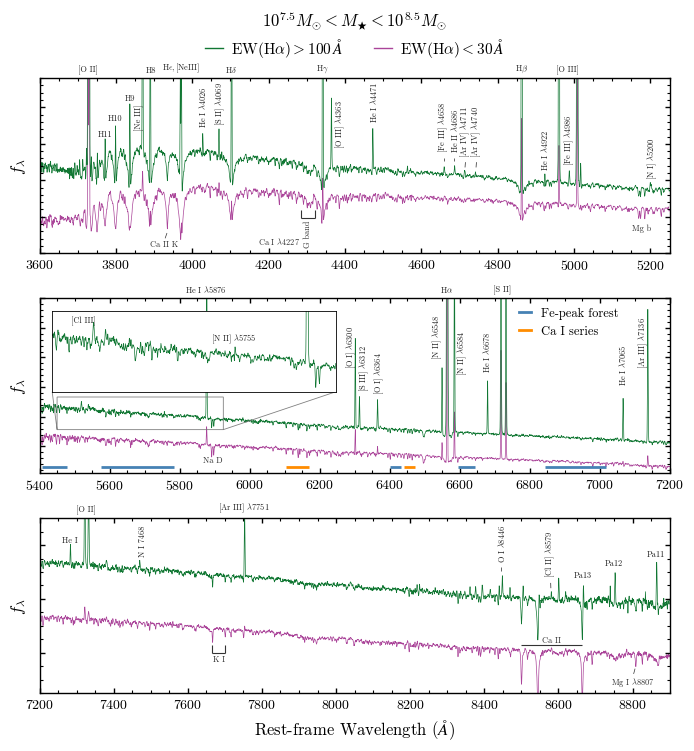

In [17]:
fig,ax = make_tall_subplots(
    nrow=3,
    ncol=1,
    panel_width=6.3,
    panel_height=1.75,
    row_spacing=[MARGIN_LABEL-0.45, MARGIN_TICKS, MARGIN_TICKS, MARGIN_LABEL-0.1],
    col_spacing=[MARGIN_LABEL-0.45, MARGIN_PAD],
    return_fig=True,
)

lw_val = 0.5

for i in range(3):
    #we want to make them such that they have same continuum level and then shift things linearly around
    ax[i][0].plot(wave,flux_100[0], lw = lw_val, color= "#117733", zorder=1)

    ax[i][0].plot(wave,flux_30[0]*scale_factor - 0.0025, lw = lw_val, color= "#AA4499", zorder=0)
    
    ax[0][0].set_ylim(0,0.024)
    ax[1][0].set_ylim(0.00275,0.0175)
    ax[2][0].set_ylim(0.0005,0.007)
    ax[i][0].set_yticklabels([])

    ax[0][0].set_xlim([3600,5250])
    ax[1][0].set_xlim([3600+ 1800,3600+ 1800 + 1800])
    ax[2][0].set_xlim([3600+ 1800 + 1800,3600+ 1800 + 1800 + 1800 - 100])

    label_lines(ax[i][0], style=STYLE, # exclude=["highion"]
                fiducial=0.5, end_y=0.24, gap=0.03, fontsize=6)

    # individual absorption features -> labels hang BELOW the trace (vacuum frame
    # so ticks land on the troughs). Self-filters to the lines within each panel.
    label_lines(ax[i][0], lines=INDIV_ABS_SINGLE, style=STYLE_ABS,
                air_to_vacuum=True, below=True, color="0.2",
                fiducial=0.15, end_y=0.40, gap=0.025, fontsize=6)
    


# ============ inset zoom: He II 4686 / [Ar IV] region, top panel ============
p = ax[1][0]
zoom_lo, zoom_hi = 5450, 5925                      # rest-frame window to magnify
axins = p.inset_axes([0.02, 0.465, 0.45, 0.46])     # [x0, y0, w, h] in axes-fraction

axins.plot(wave, flux_100[0], lw=lw_val, color="#117733", zorder=1)
axins.set_xlim(zoom_lo, zoom_hi)

m = (wave >= zoom_lo) & (wave <= zoom_hi)           # auto y-limits from data in window
ylo, yhi = flux_100[0][m].min(), flux_100[0][m].min() + 0.001
pad = yhi - ylo
axins.set_ylim(ylo - 0.15*pad, yhi + 1.6*pad)       # top headroom for the labels
axins.set_yticklabels([]); #axins.tick_params(labelsize=4.5, length=2, pad=1)
axins.set_yticks([])
axins.set_xticklabels([])
axins.set_xticks([])

for s in axins.spines.values(): s.set_linewidth(0.6)

inset_lines = [l for l in LINES if l.id in {"NII5755", "ClIII5518", "ClIII5538"}]
label_lines(axins, lines=inset_lines,
            style= { "NII5755": dict(dy=0.075, angle=0, noline=True),
                    "ClIII5518":  dict(dx=-15,  dy=0.325, angle = 0, noline=True ),
                    "ClIII5538":  dict(noline=True )},
            fiducial=0.50, end_y=0.10, gap=0.05)

rp,cn = p.indicate_inset_zoom(axins, edgecolor="0.45", lw=0.6, alpha=0.9)

cn[3].set_visible(False)   # turn off upper-right connector
cn[2].set_visible(True)    # turn on lower-right connector


###################################

# ============ absorption families + grouped brackets + legends ============
from matplotlib.lines import Line2D

# -- family "forests" as DISCONNECTED clumps (gap-clustered) so the real gaps show,
#    rather than one solid bar implying continuous coverage. Panel 1 only, stacked. --
mark_span(ax[1][0], waves=FEI_FOREST_AIR, cluster_gap=90, min_members=3, y=0.035,
          air_to_vacuum=True, color=FEI_FOREST_COLOR, lw=2)
mark_span(ax[1][0], waves=CAI_SERIES_AIR, cluster_gap=90, min_members=3, y=0.035,
          air_to_vacuum=True, color=CAI_SERIES_COLOR, lw=2)

# -- grouped multiplet / band brackets: one label each, tips up, label below --
brk = dict(tip_dir=+1, label_va="top",
           color="0.2", lw=0.8, air_to_vacuum=True)
mark_span(ax[0][0], 4285.0-1, 4320.0-1, y=0.20, label="G band", tip_len=0.045,label_dy=-0.012, angle = 90, **brk)   # Panel 0
mark_span(ax[2][0], 7664.9-1, 7699.0-1, y=0.23, label="K I", tip_len=0.045,label_dy=-0.012,   **brk)   # Panel 2
# mark_span(ax[2][0], 8183.26, 8194.83, y=0.23, label="Na I", tip_len=0.045,label_dy=-0.012, **brk)   # Panel 2, "Na 8190" (blends w/ Fe/Mg 8199-8220)
mark_span(ax[2][0], 8498.0, 8662.1, y=0.275, label="Ca II", tip_len = 0,label_dy=+0.05, **brk)   # Panel 2

# -- two frameless legends (frameon=False comes from the rcParams); positions tuned
#    against the real EW>100 stack -> both sit in empty zones. Nudge if needed. --

ax[0][0].set_title(r"$10^{7.5} M_{\odot} < M_{\bigstar} < 10^{8.5} M_{\odot}$", y=1.25)

ax[0][0].legend(                                                     # Panel 0: the stacks
    [Line2D([], [], color="#117733", lw=1.0),
     Line2D([], [], color="#AA4499", lw=1.0)],
    [r"EW(H$\alpha)>100\,\AA$", r"EW(H$\alpha)<30\,\AA$"],
    loc="lower center", bbox_to_anchor=(0.5, 1.075), ncol = 2,
    handlelength=1.2, handletextpad=0.5, borderaxespad=0.0, labelspacing=0.3)

ax[1][0].legend(                                                     # Panel 2: family bars
    [Line2D([], [], color=FEI_FOREST_COLOR, lw=2),
     Line2D([], [], color=CAI_SERIES_COLOR, lw=2)],
    ["Fe-peak forest", "Ca I series"],
    loc="upper center", bbox_to_anchor=(0.84, 1.0),
    handlelength=1, borderaxespad=0.3, fontsize = 9)


ax[0][0].set_ylabel(r"$f_{\lambda}$")
ax[1][0].set_ylabel(r"$f_{\lambda}$")
ax[2][0].set_ylabel(r"$f_{\lambda}$")


ax[2][0].set_xlabel(r"Rest-frame Wavelength ($\AA$)")

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stacked_spectra_viz.pdf")

plt.show()

In [8]:
# np.save("/pscratch/sd/v/virajvm/trash/hisnr_spec_stack.npy", np.array([wave,flux_100[0]]) )